# CRISP DM para un problema de machine learning supervisado de regresión

# Introducción al modelado

### con árboles de decisión

En este notebook, recorreremos las fases de CRISP-DM para resolver un problema de aprendizaje supervisado de regresión utilizando árboles de decisión.

El problema que vamos a resolver consiste en poder modelar el precio de un carro usado utilizando sus características.

Datos provienen de: https://www.kaggle.com/datasets/sidharth178/car-prices-dataset

![Image of car](https://storage.googleapis.com/kaggle-datasets-images/1479517/2444963/1aaa3760e7dd34a87af175482c1514ae/dataset-cover.jpg?t=2021-07-21-09-56-46)

##### Importaciones

In [1]:
1+1

2

In [2]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
from datetime import datetime
import warnings
plt.rcParams.update({'font.size': 14})
warnings.filterwarnings('ignore')


Imprimimos aquí las versiones de numpy, sklearn y pandas. Notar que en los ejemplos si no se usan las mismas versiones, puede haber leves diferencias en los resultados pero igual deberían funcionar correctamente.


In [3]:
np.__version__

'1.23.4'

In [4]:
pd.__version__

'1.3.0'

In [5]:
sklearn.__version__

'1.3.0'

## 1. Entendimiento de negocio

Aquí, en un ejercicio completo (como el del taller), se deberían hacer las diversas tareas e ítems que corresponden al entendimiento del negocio.

Como este caso es un ejemplo introductorio, solamente incluiré la problemática.

La problemática a resolver es que se busca poder estimar el precio de un vehículo usando las distintas características que lo componen, para de esta forma poder asignar un precio justo a cada uno de ellos al momento de su venta.

Este problema corresponde entonces a un problema supervisado de regresión (aprender a predecir el precio de carros usando sus características), que es el tipo de problemas de machine learning que veremos en este curso.

Recordemos entonces que las demás actividades del entendimiento de negocio quedan como ejercicio sugerido (estas se tendrían que hacer en un proyecto real):
- Preguntas de negocio
- Limitaciones
- Riesgos
- Objetivos analíticos (métricas a usar, que se va a optimizar, etc)
- etc.


## 2. Entendimiento de datos




Procedamos entonces ahora con la fase de entendimiento de datos.

#### Nota:

En este ejemplo introductorio no se incluyó, pero un problema real, sería muy bueno al inicio de esta etapa incluir el Diccionario de datos o de variables, para poder concoer muy bien nuestro conjunto de datos qué tiene y cuál es la descripción y contenido de cada una de las columnas.

### Carga de datos

Procedamos entonces primero a cargar los datos (asumiendo que ya entendemos bien la descricpión del conjunto y de sus columnas, lo cuál se vería en el diccionario de datos).

In [6]:
data_raw=pd.read_csv('CarPrices.csv')
data_raw.shape

(19225, 17)

### Análisis descriptivo

Ahora procedamos con el análisis descriptivo para entender mejor los datos.

Miremos ahora primero la información del conjunto de datos para ver un poco la descripción del dataframe.

In [7]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19225 entries, 0 to 19224
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19225 non-null  int64  
 1   Price             19225 non-null  int64  
 2   Manufacturer      19225 non-null  object 
 3   Model             19225 non-null  object 
 4   Prod. year        19225 non-null  int64  
 5   Category          19225 non-null  object 
 6   Leather interior  19225 non-null  object 
 7   Fuel type         19225 non-null  object 
 8   Engine volume     19225 non-null  object 
 9   Mileage           19225 non-null  object 
 10  Cylinders         19225 non-null  float64
 11  Gear box type     19225 non-null  object 
 12  Drive wheels      19225 non-null  object 
 13  Doors             19225 non-null  object 
 14  Wheel             19225 non-null  object 
 15  Color             19225 non-null  object 
 16  Airbags           19225 non-null  int64 

El info nos muestra los tipos de las columnas. Nos sirve por ejemplo para ver que hay muchas variables que se están leyendo como object (String) cuándo esperaríamos que fueran numéricas: Mileage (Millas totales), Doors (Puertas), etc, lo que indica posibles problemas de formato.

Miremos ahora el head y el tail.

In [8]:
data_raw.head(12)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45816158,549,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,45641395,1098,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,45756839,26657,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [9]:
data_raw.tail(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19215,45763841,470,HYUNDAI,Elantra,2017,Sedan,Yes,Petrol,1.6,25635 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
19216,45784464,37633,TOYOTA,RAV 4,2017,Jeep,Yes,Petrol,2.5,23430 km,4.0,Tiptronic,Front,04-May,Left wheel,Beige,12
19217,45804344,26017,LEXUS,ES 300,2009,Sedan,Yes,Petrol,3.5,132700 km,4.0,Automatic,Front,04-May,Left wheel,White,4
19218,45748699,30,NISSAN,Note,2006,Hatchback,No,Petrol,1.3,0 km,4.0,Automatic,Front,04-May,Right-hand drive,Green,9
19219,45789241,19444,TOYOTA,Prius,2013,Sedan,No,Hybrid,1.8,140607 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
19220,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
19221,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
19222,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
19223,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4
19224,45768089,19130,KIA,Optima ex,2014,Sedan,Yes,Petrol,2.4,35800 km,4.0,Automatic,Front,04-May,Left wheel,Black,12


Del head y tail se ven algunas cosas interesantes, como por ejemplo:

- Pareciera que los Hyundai tienen precios más altos que los demás.
- Hay algunas columnas con problemas de conformidad (ejemplo la de Doors (puertas) pareciera una fecha). Lo que se asume es que 02-Mar es en realidad "2-3" (2 o 3 puertas), y 04-May es en realidad "4-5" puertas, y esto se dañó en algún momento en la generación del dataset.
- En general pareciera que la mayoría de los carros tienen modelos cercanos a 2010 salvo por algunas excepciones.
- La mayor parte de los carros parecen ser automáticos (algo común en Estados Unidos).
- Hay un par de autos con precios excesivamente bajos, por ejemplo uno de ellos tiene un precio de solo 50 dólares. Se debe revisar con el equipo de negocio que puede pasar en estos porque pueden que se estén vendiendo como chatarra.
- Hay un par de variables que según nuestro conocimiento de negocio posiblemente no afecten tanto en el precio (cómo el color del carro y sobre todo su ID).

Por último en la parte de análisis descriptivo, miremos el describe.

In [10]:
data_raw.describe(include="all")

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
count,1.922500e+04,1.922500e+04,19225,19225,19225.000000,19225,19225,19225,19225,19225,19225.000000,19225,19225,19225,19225,19225,19225.000000
unique,NaN,NaN,65,1590,NaN,11,2,7,107,7685,NaN,4,3,3,2,16,NaN
top,NaN,NaN,HYUNDAI,Prius,NaN,Sedan,Yes,Petrol,2,0 km,NaN,Automatic,Front,04-May,Left wheel,Black,NaN
freq,NaN,NaN,3766,1081,NaN,8730,13944,10148,3914,721,NaN,13506,12867,18321,17742,5030,NaN
mean,4.557671e+07,1.856181e+04,NaN,NaN,2010.914278,NaN,NaN,NaN,NaN,NaN,4.582939,NaN,NaN,NaN,NaN,NaN,6.582003
std,9.359993e+05,1.906404e+05,NaN,NaN,5.669212,NaN,NaN,NaN,NaN,NaN,1.200075,NaN,NaN,NaN,NaN,NaN,4.320223
min,2.074688e+07,1.000000e+00,NaN,NaN,1939.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4.569830e+07,5.331000e+03,NaN,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,4.577228e+07,1.317200e+04,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,6.000000
75%,4.580204e+07,2.210600e+04,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,12.000000


#### Ejercicio:
Analice los patrones interesantes que se vean en el describe.

### Sobre las dimensiones de calidad de datos
Tener en cuenta que aquí procederíamos a mirar ahora una por una las dimensiones de calidad de datos, pero en este ejemplo introductorio no entraremos tan a detalle. Queda entonces como ejercicio sugerido mirar una por una las dimensiones de calidad de datos. 

Solo recordaremos por ahora los detalles interesantes a corregir que mencionamos anteriormente, como por ejemplo los autos que parecen venderse como chatarra y que algunas variables tienen un formato inesperado (como por ejemplo la de Mileage).

Así, por ahora solo haremos hasta aquí el entendimiento de datos, pero en un problema real se recuerda que se debe hacer mucho más a detalle con las demás etapas vistas en clase.

## 3. Preparación de datos

### Selección del conjunto de datos a usar


#### Tratamiento de outliers muy evidentes (precio)

En este caso, para el ejercicio me enfocaré solamente en los carros con valores de al menos mil dólares. Esto es debido a que hay varios de ellos con valores de menos de mil dólares, pero es muy raro que un carro cueste eso por lo que puede ser algún error de los datos o que se estén vendiendo como chatarra, lo cuál no es algo que querré incluir en mi análisis 

(Notar que al hacer este descarte, debo confirmar que el equipo de negocio esté de acuerdo. Por ejemplo, si ellos me dijeran que sí les interesan estos carros de menos de mil dólares así sean chatarra, no podría quitar las filas de estos, pero tend´ria que pensar si es posible agregar una nueva columna que indique si un auto es chatarra o no).

In [11]:
data_filtered = data_raw[data_raw["Price"]>=1000]
data_filtered

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19220,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
19221,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
19222,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
19223,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4


##### Cuidado

Actualmente, el valor promedio de los precios de los vehículos es

In [12]:
# Valor promedio de los precios de los vehiculos
data_filtered["Price"].mean()

21361.078234764336

Sin embargo, del describe se debió haber notado un valor extremadamente alto en el precio máximo (un carro con precio de 26.7 millones de dólares).
Miremos los carros ordenados por precio a ver si pasó algo raro:

In [13]:
data_filtered.sort_values(by="Price", ascending=False).head(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16983,45812886,26307500,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999 km,4.0,Manual,Front,02-Mar,Left wheel,Blue,0
8541,45761204,872946,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4,2531 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,0
1225,45795524,627220,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3 Turbo,0 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,12
5008,45810285,308906,PORSCHE,911,2016,Coupe,Yes,Petrol,4,8690 km,6.0,Automatic,Rear,02-Mar,Left wheel,Black,12
9367,45229113,297930,MERCEDES-BENZ,AMG GT S,2015,Coupe,Yes,Petrol,4.0 Turbo,20000 km,8.0,Tiptronic,Rear,02-Mar,Left wheel,White,16
14839,45792307,297930,LAND ROVER,Range Rover Vogue,2019,Jeep,Yes,Diesel,3.0 Turbo,4500 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,12
7749,45760644,288521,BMW,M5 Машина в максимально,2018,Sedan,Yes,Petrol,4.4,13500 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,0
10759,45291161,260296,LEXUS,LX 570,2018,Jeep,Yes,Petrol,5.7 Turbo,17700 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,10
5840,44991441,254024,MERCEDES-BENZ,GLE 400 A M G,2016,Jeep,Yes,Petrol,3.0 Turbo,73000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,12
15283,45069516,250574,MERCEDES-BENZ,GLE 400,2017,Jeep,Yes,Petrol,3.0 Turbo,81600 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,12


Claramente, ese primer carro OPEL está demasiado raro, porque es un auto de 1999 que vale 26.7 millones de dólares. 

Conservar ese carro en nuestro dataset dañaría todos los modelos, por lo que lo voy a quitar (si quieren, en otra ocasión prueben como tarea sugerida que pasaría si no hubieran quitado este único dato, y verán que más adelante todos los modelos dan extremadamente diferentes en sus métricas puesto que se enfocarían mucho en ese único carro).

El segundo carro más costoso vale 800mil dólares, lo cual es un valor alto pero razonable teniendo en cuenta que es un lamborghini.

In [14]:
# Quitar auto de mas de 20 millones de 
data_filtered = data_filtered[data_filtered["Price"]<20000000]
data_filtered

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19220,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
19221,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
19222,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
19223,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4


In [15]:
max(data_filtered["Price"])

872946

Para evitar problemas a futuro, luego de los filtrados reseteo el index:


In [16]:
# Tambien reseteo el index para evitar problemas a futuro
data_filtered = data_filtered.reset_index(drop=True)
data_filtered


,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16649,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
16650,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
16651,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
16652,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4


Observen como cambia ahora el valor promedio de los precios de los vehículos. 

In [17]:
# Valor promedio de los precios de los vehiculos
data_filtered["Price"].mean()

19782.71033985829

Un único valor outlier cambió 1600 dólares el precio promedio del total del conjunto total de 16 mil carros!!! 

Esto es prácticamente un cambio del 10% en el valor promedio de todos los carros, lo cuál es un cambio muy grande para una empresa (piensen que pasaría si a una empresa le decimos de repente que sus ventas estaban "mal calculadas" y en realidad son 10% menos de lo que se pensaba... esto puede representar una diferencia de varios millones de dólares en su presupuesto!).

Y tengan en cuenta entonces que, de la misma forma que este dato afectó muchísimo la media, afectaría también muchísimos los modelos de machine learning que creemos, puesto que muchos de ellos para entrenarse usan métodos que se verían muy afectados por este valor (como por ejemplo el error cuadrático medio). 

Recuerden por ejemplo como en una regresión lineal la recta de regresión se puede desviar muy notablemente por culpa de un solo valor outlier: esto mismo pasaría en gran parte de los demás modelos de machine learning. (Link: https://www.google.com/search?client=firefox-b-d&sca_esv=566149086&q=linear+regression+with+an+outlier&tbm=isch&source=lnms&sa=X&ved=2ahUKEwjm28XFhrOBAxXjlWoFHWaYB0IQ0pQJegQIDRAB&biw=1366&bih=615&dpr=1#imgrc=zG2A1fmcPTyJGM)

Así, se nota aquí el efecto tan catastrófico que puede tener un solo outlier en el conjunto de datos.

### Seleccionar variables de interés

Por ahora, vamos a empezar por seleccionar solo algunas de las columnas de nuestro conjunto de datos. 

Ya sabíamos que hay algunas que posiblemente no sean tan importantes por lo que podemos pensar en omitirlas (color, ID, etc.).

Además, sabemos que hay muchas otras que necesitan preparaciones adicionales para poderse usar (ejemplo el Mileage que no venía numérico).

Así, para empezar con nuestras variables elegidas, por ahora tomemos solamente las que ya estaban listas para usar, que serían:

In [18]:
data_elegida = data_filtered[["Price", "Cylinders", "Airbags", "Prod. year"]]
data_elegida.head()

,Price,Cylinders,Airbags,Prod. year
0,13328,6.0,12,2010
1,16621,6.0,8,2011
2,8467,4.0,2,2006
3,3607,4.0,0,2011
4,11726,4.0,4,2014


### Preparación y selección de características a usar

Entremos ahora a hacer todas las preparaciones y correcciones necesarias para poder usar las demás columnas de interés en nuestro conjunto de datos. Recordemos que los modelos necesitan que las variables sean numéricas para poderlas usar.

##### Corrección de formatos:
Convertir primero la columna de mileage a algo útil (quitar el km) y que sea numerica.
Y agregar dicha variable al conjunto de datos.

In [19]:
# Columna antigua de Mileage
mileage = data_filtered["Mileage"]

# Quitar el " km"
kilometraje = mileage.str.replace(" km", "")

# Volverla numerica y pegarla a las variables elegidas
data_elegida["Kilometraje"] = pd.to_numeric(kilometraje)
data_elegida.head()

,Price,Cylinders,Airbags,Prod. year,Kilometraje
0,13328,6.0,12,2010,186005
1,16621,6.0,8,2011,192000
2,8467,4.0,2,2006,200000
3,3607,4.0,0,2011,168966
4,11726,4.0,4,2014,91901


#### Label encoding para variables categóricas:

Recordar que nuestros modelos usualmente no podrán procesar por defeto variables categóricas (Strings), ya que están diseñados para trabajar con variables numéricas.

Por ende, hay que hacer una preapración a estas variables para poderlas usar, la cual se llama "label encoding". El label encoding convierte las variables categóricas en variables numéricas que el modelo ya sí podrá utilizar.

Hay muchos tipos de label encoding, pero aquí solo usaremos los dos principales según el caso:

- Cuando las variables son nominales (no importa el orden), se debe usar one-hot encoding. Este crea una nueva columna binaria en 0 o 1 por cada categoría de la columna. Es recomendada cuando las categorías no tienen un orden (ejemplo: azul, verde, rojo, negro, amarillo).

- Cuando las variables son ordinales (sí importa el orden), se debe usar ordinal encoding. Este crea una sola nueva columna para todo el conjunto, en donde asigna un número de 0 a n a cada una de las categorías según su orden. Es recomendada cuando las categorías sí tienen un orden (ejemplo: deficiente, malo, regular, bueno, excelente).


Apliquemos entonces ahora encoding a la categoría "drive wheels", que indica en cuáles llantas tienen tracción los carros (delanteras, traseras o en todas).

Cómo esta columna no tiene un orden claro, aplicamos one-hot encoding.

In [20]:
onehot_wheels = pd.get_dummies(data_filtered["Drive wheels"])
data_elegida = data_elegida.join(onehot_wheels)
data_elegida.head()

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear
0,13328,6.0,12,2010,186005,1,0,0
1,16621,6.0,8,2011,192000,1,0,0
2,8467,4.0,2,2006,200000,0,1,0
3,3607,4.0,0,2011,168966,1,0,0
4,11726,4.0,4,2014,91901,0,1,0


Ahora, usando label encoding, preparemos la variable "Doors" para que también la podamos usar en el modelo. Esta variable indica el número de puertas posibles que puede tener un carro (2-3, 4-5 o más de 5). Tener en cuenta que aquí sí se puede considerar un orden en estas 3 categorías, por lo que se debe usar Ordinal Encoding. Recordar agregarla al conjunto a usar.

In [21]:
# Como ayuda, puedo usar el método unique para ver las categorías únicas de una variable
data_filtered["Doors"].unique()


array(['04-May', '02-Mar', '>5'], dtype=object)

In [22]:
# Ahora si, proceder a prepararla con Ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

# Columna de doors antigua
doorsdf = data_filtered[["Doors"]]

# Defino la jerarquía u orden de las categorías, de menor a mayor
# (el número que se le asignará a cada uno dependerá de esto: 0 al primer elemento, 1 al segundo, etc...)
orden = ['02-Mar','04-May','>5']

# Crear el encoder

enc = OrdinalEncoder(categories=[orden])

# Aplicar el encoding
doorsnew = enc.fit_transform(doorsdf)

# Pegar la columna al dataframe de elegidas
data_elegida["Puertas"] = pd.DataFrame(doorsnew)
data_elegida.head()


,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,13328,6.0,12,2010,186005,1,0,0,1.0
1,16621,6.0,8,2011,192000,1,0,0,1.0
2,8467,4.0,2,2006,200000,0,1,0,1.0
3,3607,4.0,0,2011,168966,1,0,0,1.0
4,11726,4.0,4,2014,91901,0,1,0,1.0


(Ojo: aquí la columna "Puertas" tendría un valor de 0 si tiene 2-3 puertas, 1 si tiene 4-5 puertas y 2 si tiene más de 5 puertas).

##### Validemos como va todo hasta aquí

Para validar que todo va bien hasta acá, comparemos algunas filas del dataset antes y después de la preparación de características.


In [23]:
data_filtered.head(10)

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45641395,1098,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
8,45756839,26657,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
9,45814819,8781,FORD,Transit,1999,Microbus,No,CNG,4,0 km,8.0,Manual,Rear,02-Mar,Left wheel,Blue,0


In [24]:
data_elegida.head(10)

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,13328,6.0,12,2010,186005,1,0,0,1.0
1,16621,6.0,8,2011,192000,1,0,0,1.0
2,8467,4.0,2,2006,200000,0,1,0,1.0
3,3607,4.0,0,2011,168966,1,0,0,1.0
4,11726,4.0,4,2014,91901,0,1,0,1.0
5,39493,4.0,4,2016,160931,0,1,0,1.0
6,1803,4.0,12,2010,258909,0,1,0,1.0
7,1098,4.0,12,2014,398069,0,1,0,1.0
8,26657,6.0,12,2007,128500,1,0,0,1.0
9,8781,8.0,0,1999,0,0,0,1,0.0


In [25]:
data_filtered.tail()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16649,45795511,8467,MITSUBISHI,Outlander,2004,Universal,No,CNG,2.4,140000 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,6
16650,45776906,15681,VOLKSWAGEN,Jetta,2013,Sedan,Yes,Petrol,2.5,81200 km,5.0,Manual,Front,04-May,Left wheel,Silver,12
16651,45732720,10036,HYUNDAI,Sonata,2014,Sedan,Yes,LPG,2,735970 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
16652,44571028,8781,DODGE,Caliber,2008,Hatchback,No,Petrol,2.4,0 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4
16653,45768089,19130,KIA,Optima ex,2014,Sedan,Yes,Petrol,2.4,35800 km,4.0,Automatic,Front,04-May,Left wheel,Black,12


In [26]:
data_elegida.tail()

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
16649,8467,6.0,6,2004,140000,1,0,0,1.0
16650,15681,5.0,12,2013,81200,0,1,0,1.0
16651,10036,4.0,4,2014,735970,0,1,0,1.0
16652,8781,4.0,4,2008,0,0,1,0,1.0
16653,19130,4.0,12,2014,35800,0,1,0,1.0


In [27]:
len(data_filtered)

16654

In [28]:
len(data_elegida)

16654

Vemos entonces que por ahora parece ir todo bien con nuestra preparación de datos.

#### Ejercicio: 

Con la nueva variable llamada "data_elegida_copia", resuelva los siguientes puntos (NO modifique "data_elegida" para que no haya inconsistencias con el resto del notebook). 


In [29]:
data_elegida_copia = data_elegida.copy()


# Guardar este también para resetearla mas adelante
data_elegida_reset = data_elegida.copy()


Ahora, resuelva:

1. Preparar la variable "Engine_volume" para que también la podamos usar en el modelo (dejaremos solo el valor numérico que ahí se presenta, que representa los litros que tiene el motor). Recordar agregarla al conjunto (data_elegida_copia).

2. Preparar la variable "Leather interior" para que también la podamos usar en el modelo (esta indica sí el interior del carro tiene cojinería de cuero o no). Recordar agregarla al conjunto (data_elegida_copia).

3. Preparar la variable "Fuel type" para que la podamos incluir en el modelo (esta variable indica el tipo de combustible que usa el vehículo). Recordar agregarla al conjunto (data_elegida_copia).

4. Muestre el "head(15)" del conjunto de datos "data_elegida_copia" luego de preparar las 3 nuevas variables, y compárelo con el de la variable data_filtered. ¿Sí quedó bien preparado?

#### Correr esto al final para resetear las variables elegidas y no incluir las del ejercicio

In [30]:
data_elegida = data_elegida_reset.copy()
data_elegida

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,13328,6.0,12,2010,186005,1,0,0,1.0
1,16621,6.0,8,2011,192000,1,0,0,1.0
2,8467,4.0,2,2006,200000,0,1,0,1.0
3,3607,4.0,0,2011,168966,1,0,0,1.0
4,11726,4.0,4,2014,91901,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...
16649,8467,6.0,6,2004,140000,1,0,0,1.0
16650,15681,5.0,12,2013,81200,0,1,0,1.0
16651,10036,4.0,4,2014,735970,0,1,0,1.0
16652,8781,4.0,4,2008,0,0,1,0,1.0


### Un primer vistazo a la importancia de las variables

Aquí también es un buen momento para determinar cuáles variables pueden se realmente importantes para modelar esta problemática.

Esto ya se debió haber hecho desde el conocimiento del negocio; sin embargo, se puede realizar también con métodos estadísticos.

Como una guia inicial, miremos como queda la matriz de correlación lineal de los datos que tenemos hasta ahora (podemos calcular directamente la matriz de correlación al tener solo datos numéricos en nuestra data preparada, aunque hay que ser cuidadosos con su análisis).



In [31]:
data_elegida.corr()

,Price,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
Price,1.000000,0.166594,0.028887,0.329300,-0.017125,0.124247,-0.096772,-0.011633,0.032507
Cylinders,0.166594,1.000000,0.203453,-0.111540,-0.003432,0.444754,-0.554333,0.251285,-0.032440
Airbags,0.028887,0.203453,1.000000,0.239392,-0.007138,0.097887,-0.126674,0.061884,0.053443
Prod. year,0.329300,-0.111540,0.239392,1.000000,-0.063707,-0.083671,0.293860,-0.314344,0.186107
Kilometraje,-0.017125,-0.003432,-0.007138,-0.063707,1.000000,0.006136,-0.014374,0.012942,-0.007072
4x4,0.124247,0.444754,0.097887,-0.083671,0.006136,1.000000,-0.716124,-0.182018,0.030023
Front,-0.096772,-0.554333,-0.126674,0.293860,-0.014374,-0.716124,1.000000,-0.555966,0.112430
Rear,-0.011633,0.251285,0.061884,-0.314344,0.012942,-0.182018,-0.555966,1.000000,-0.194144
Puertas,0.032507,-0.032440,0.053443,0.186107,-0.007072,0.030023,0.112430,-0.194144,1.000000


Se observa algunas variables que ya vemos que nos podrán ser útiles para modelar el precio (sobre todo la de Production Year, que tiene la mayor correlación con el precio). Se observan aquí ya algunas relaciones esperadas: mientras más reciente el carro, más cuesta; a mayor número de cilindros, mayor el costo; los carros de 4x4 suelen costar más que los que no son 4x4, etc.

Es por ejemplo curioso también que el kilometraje parece no afectar casi (a futuro sería bueno analizar más a detalle el por qué de esto).

(Note que se debe complementar este análisis con nuevas variables que se hayan añadido en el ejercicio sugerido).

Por ahora solo usaremos este primer enfoque inicial para ver que variables resultaban importantes, pero es apenas un primer paso que no siempre será el más adecuado (por ejemplo, este paso asume linealidad y eso no siempre se da).

Más adelante en el curso profundizaremos más en esta y en otras matrices de correlación para entender mejor la importancia de nuestras variables en el conjunto.

#### Nota:
Por ahora, continuaremos el ejercicio usando solo las variables que hemos preparado y pulido hasta ahora.
Sin embargo, en  un ejercicio completo, se deben terminar de pulir y preparar todas las demás variables que también puedan ser de utilidad para nuestra problemática.

Como ejercicio sugerido a futuro, una vez terminemos de modelar nuestro problema, si consideramos que los resultados aún no son suficientemente buenos, podemos considerar regresar a este paso y pulir y agregar más variables para ayudar a crear mejores modelos.

### Separar las variables de entrada de la variable de salida

Ahora, separemos la variable de salida (de interés a modelar), que es el Precio, de las demás variables de entrada o explicativas que usaremos para predecir el precio.

In [32]:
var_salida = "Price"
data_x = data_elegida.drop(columns=[var_salida])
data_y = data_elegida[var_salida]

In [33]:
data_x.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,6.0,12,2010,186005,1,0,0,1.0
1,6.0,8,2011,192000,1,0,0,1.0
2,4.0,2,2006,200000,0,1,0,1.0
3,4.0,0,2011,168966,1,0,0,1.0
4,4.0,4,2014,91901,0,1,0,1.0


In [34]:
data_y.head()

0    13328
1    16621
2     8467
3     3607
4    11726
Name: Price, dtype: int64

### División de los datos en entrenamiento, validación y prueba

Antes de continuar, vamos a aplicar un procesamiento en los datos que es muy común en problemas de analítica.

Lo que vamos a hacer es dividir nuestros datos en datos de entrenamiento, validación y prueba (test).

Esto se hace para que, primero, los modelos que construyamos sean entrenado y ajustados solamente con el subconjunto de los datos que son de entrenamiento. 

Luego, vamos a comparar el rendimiento de los modelos que creamos usando el conjunto de validación para seleccionar el mejor de ellos. Nótese que en este momento los modelos solo se pudieron entrenar con los datos de entrenamiento, por lo que en esta competencia para seleccionar el mejor usaremos los datos de validación para ver cómo se comportan con datos nuevos (que es lo realmente importante). 

Y por último, entrenamos el modelo seleccionado usando todos los datos de entrenamiento y validación y vemos cómo le fue a en el conjunto de prueba para ver como es su rendimiento. Esto se hace para tener más similitudes con un comportamiento real: cuando vaya a usar el modelo en condiciones reales, lo usaré sobre datos que no existían y que el modelo jamás había visto. Por eso debo usarlo sobre los datos que deje aparte como conjunto de prueba.


En este caso, asumiré que el 60% serán datos de entrenamiento, el 20% serán de validación el 20% restante serán los de prueba. 

Se sugiere hacer esta división de los datos de forma aleatoria para evitar que queden sesgados o desbalanceados los grupos (y conservar la semilla aleatoria usada para reproducibilidad).




In [35]:
## Dividir en entrenamiento, validación y prueba
# Importar metodo para dividirlos
from sklearn.model_selection import train_test_split

# Fijare una semilla aleatorios para que sean reproducibles los conjuntos
semilla = 42

# Proporcion de datos en train, validation y test
train_ratio = 0.6
validation_ratio = 0.2
test_ratio = 0.2

# Realizar la division en dos pasos (primero train y val/test, y luego val/test en validation y test)
x_train, x_val_test, y_train, y_val_test = train_test_split(data_x, data_y, test_size= validation_ratio + test_ratio, random_state = semilla)
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state = semilla) 


In [36]:
x_train.shape

(9992, 8)

In [37]:
x_train.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
13854,4.0,12,2011,142000,0,1,0,1.0
5938,4.0,12,2014,151923,0,1,0,1.0
4320,4.0,8,2013,67224,0,1,0,1.0
11828,4.0,4,2012,132421,0,1,0,1.0
2107,4.0,10,2014,130000,0,1,0,1.0


In [38]:
y_train.head()

13854    17249
5938      4391
4320     17562
11828    20005
2107     16935
Name: Price, dtype: int64

In [39]:
x_val.shape

(3331, 8)

In [40]:
x_val.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
10210,8.0,6,2013,64023,1,0,0,1.0
14442,8.0,0,2013,154115,1,0,0,1.0
4671,4.0,4,2011,192085,0,1,0,1.0
9664,4.0,12,2016,23000,0,0,1,1.0
6491,4.0,4,2012,120334,0,1,0,1.0


In [41]:
y_val.head()

10210    27598
14442     1490
4671     18647
9664     46101
6491     18826
Name: Price, dtype: int64

In [42]:
x_test.shape

(3331, 8)

In [43]:
x_test.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
5483,4.0,10,2012,112000,0,1,0,1.0
8821,4.0,4,2015,409910,0,1,0,1.0
1215,6.0,12,2011,119379,1,0,0,1.0
3950,4.0,2,2004,229000,0,1,0,1.0
13558,4.0,10,2016,75851,0,1,0,1.0


In [44]:
y_test.head()

5483     18817
8821     15367
1215     16621
3950      8154
13558    26030
Name: Price, dtype: int64

#### Sobre el escalamiento de los datos:

En este punto, sería un buen momento para aplicar escalamiento de los datos.

Esto sirve para que nuestras variables todas queden en la misma escala (ejemplo: es muy distinto tener una diferencia de una unidad en los litros del motor (que suelen tener valores no mayores a 4) que tener una diferencia de una unidad en el kilometraje total del auto (que suele estar en decenas o cientos de miles)).

El tener varias escalas puede afectar notablemente a muchos tipos de modelos de Machine Learning y hacer que su resultado no sea adecuado. Sin embargo, en particular en el modelo que estamos usando (árboles de decisión), las diversas escalas no afectan casi este modelo, por lo que aquí no es 100% necesario aplicar escalamiento y procederemos sin él

Tenga en cuenta que en muchos otros modelos este escalamiento toma mayor importancia (regresiones lineales y no lineales; redes neuronales, etc), por lo que hay que recordar aplicarlo en esos casos.

Hay varios tipos de escalamiento, dos de los más comunes son estandarización (Standard scaling) y normalización Min-Max ( min-max scaling). Se deja como sugerido estudiarlos.

### Resumen final de la fase de entendimiento y preparación de datos

Se deja como ejercicio sugerido la opción de profundizar mucho más en las demás tareas del entendimiento y preparación de datos, ya que pueden ser complementadas y realizadas con lo visto en clases pasadas:
- Dimensiones de calidad
- Manejo de faltantes
- Tratamiento de outliers
- Visualizaciones
- Escalamiento
- Preparar y pulir más variables
- Importancia de variables (tema que será visto en el módulo 4)
- Etc.

En un ejercicio completo de analítica, donde se sigan a profundidad todas las fases del Crisp-DM, se deben realizar todas estas tareas. Sin embargo, en este ejemplo solo llegaremos hasta aquí para enfocarnos ahora en la parte de modelado.

## 4. Modelado

Ahora sí, comencemos con la fase de modelado.

Cómo hemos dicho, en este curso nos enfocaremos en modelos basados en árboles de decisión para resolver esta problemática.

Por ende, usemos entonces por ahora un árbol de decisión para modelar el problema.

### Construir y entrenar un modelo para resolver el problema

En este caso, como es un problema supervisado de regresión, usaremos el DecisionTreeRegressor de la librería scikit-learn.

In [45]:
## Importar el árbol de decisión
from sklearn.tree import DecisionTreeRegressor

Luego de importarlo, inicializamos una variable con el árbol de decisión. Vamos a usar una profundidad máxima del árbol de 3 niveles. Para los demás hiperparámetros usaremos el valor por defecto en este caso.

In [46]:
# Creamos el modelo
dtr1 = DecisionTreeRegressor(random_state = semilla, max_depth = 3) # Fijo la semilla aleatoria y usar profundidad max de 3

Por último, entrenamos entonces nuestro árbol de decisión, usando el conjunto de entrenamiento y sus variables explicativas (x_train) para predecir su variable de salida que es el precio (y_train).

In [47]:
# Entrenar el modelo con los datos de entrenamiento
dtr1.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

Ya tenemos entonces construido y entrenado nuestro primer modelo de árboles de decisión.

Miremos como quedó el árbol generado:

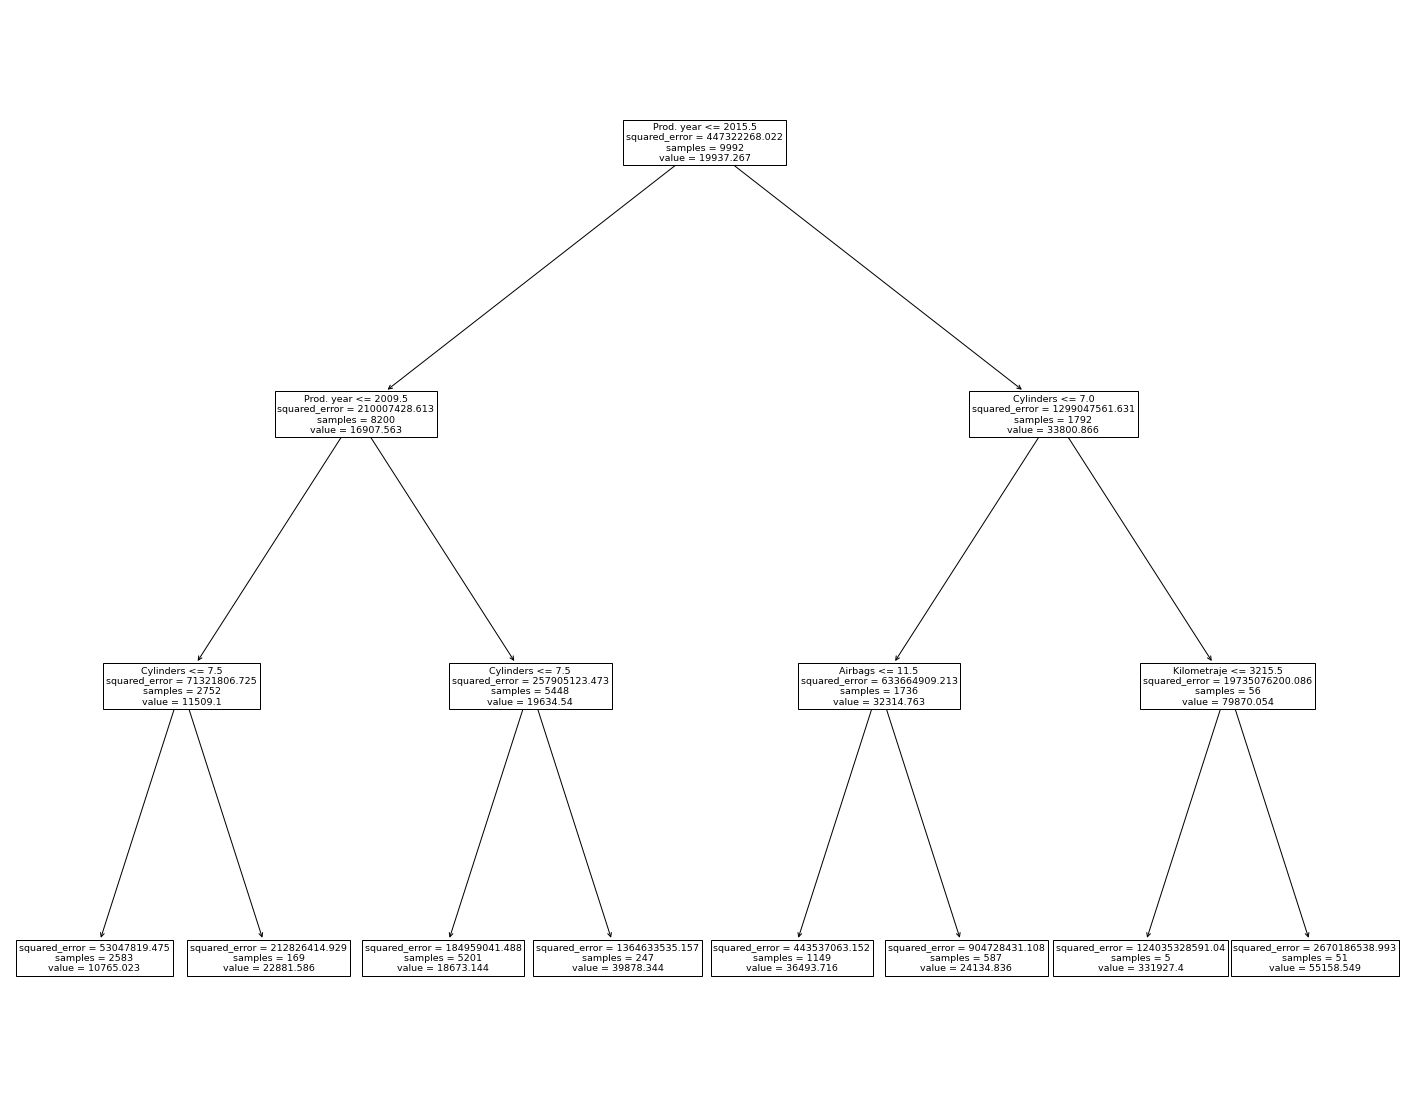

In [48]:
# PINTER AQUI ARBOL DE DECISION GENERADO
import matplotlib.pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dtr1, feature_names = list(x_train.columns))

Del gráfico vemos que la primera variable usada es el año de producción (lo cuál tiene sentido considerando que era la de mayor correlación), por lo que parece ser que en el primer nivel efectivamente es la variable más importante (la que más ayuda a reducir la entropía). En los niveles 2 y 3 vemos que se usan otras variables como cilindros, airbags, kilometraje y de nuevo el año de producción. Hay algunas que ni siquiera aparecen, puede que sean un poco menos importantes aunque también es cierto que 3 niveles son muy pocos (no se debe tener demasiados niveles pero tampoco un número muy bajo de estos).

### Contrucción de otros modelos y selección del mejor modelo en el conjunto de validación

Ahora, probemos otras opciones de modelos y procedamos a elegir cuál es nuestro modelo en el conjunto de validación.

Podemos construir varios posibles modelos con lo que hemos visto hasta ahora. Uno de ellos es el que acabamos de crear; sin embargo, notar que podemos cambiar el modelo completamente de dos formas principales:

1. Cambiando las variables que usa (modificando la preparación de características).
2. Cambiando los hiperparámetros del modelo.

Al tener varios posibles modelos, vamos a revisar el rendimiento que cada uno de ellos obtendría en el conjunto de validación y elegir el mejor de ellos según sus métricas.

En este caso, cambiaremos los hiperparámetros del modelo para crear otro par más de modelos, y luego pondremos a competir todos para elegir el que sea mejor.

In [49]:
## Crear y entrenar modelo 2, poniendo otra profundidad
dtr2 = DecisionTreeRegressor(random_state = semilla, max_depth = 7)
dtr2.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=7, random_state=42)

In [50]:
## Crear y entrenar modelo 3, poniendo en este caso un número mínimo de 4 observaciones para que consideremos
# que ya llegamos al final de una de las ramas del árbol (y por ende ser un nodo hoja)
dtr3 = DecisionTreeRegressor(random_state = semilla, min_samples_leaf = 4)
dtr3.fit(x_train, y_train)

DecisionTreeRegressor(min_samples_leaf=4, random_state=42)

#### Comparar rendimientos en validación

Ahora sí, calculemos las métricas en validación de nuestros modelos y elijamos el mejor de ellos. Debemos entonces, para cada modelo, generar las predicciones en el conjunto de validación, y comparar estas precicciones con los datos reales de validación para calcular las métricas.


In [51]:
# Predicciones en validacion de los 3 modelos
pred_val1 = dtr1.predict(x_val)
pred_val2 = dtr2.predict(x_val)
pred_val3 = dtr3.predict(x_val)


En nuestro curso, las métricas que usaremos en estos problemas son el MAE, el MSE y el MAPE para compararnos. Estas métricas son de error, por lo que se espera minimizarlas.

In [52]:
# Mirar metricas en validacion de cada uno
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

In [53]:
# Modelo 1
print("Metricas modelo 1: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val1)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val1)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val1)))

Metricas modelo 1: 
MSE: 230457158.70487177
MAE: 9724.560110684952
MAPE: 1.3126861081628494


In [54]:
# Modelo 2
print("Metricas modelo 2: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val2)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val2)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val2)))

Metricas modelo 2: 
MSE: 201814276.52500802
MAE: 8477.347091210399
MAPE: 0.9992404289908265


In [55]:
# Modelo 3
print("Metricas modelo 3: ")
print("MSE: " +  str(mean_squared_error(y_val, pred_val3)))
print("MAE: " + str(mean_absolute_error(y_val, pred_val3)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_val, pred_val3)))

Metricas modelo 3: 
MSE: 209937506.66267857
MAE: 8097.529298112653
MAPE: 0.8129290406298239


De esta forma, elegiremos entonces el modelo con mejores métricas (para este caso, buscar el valor menor para estas 3 métricas, pero notar que hay muchas otras métricas fuera de estas 3 en las que puede que se busque valores mayores como el R2).


El modelo 1 vemos que presenta el peor resultado entre los 3 ya que en las 3 métricas es el peor, por lo que sabemos 100% que no es el mejor.

Entre el modelo 2 y 3, es un poco más difícil decidir, ya que en MSE gana el 2 pero en MAE y MAPE gana el 3. Esto es algo que pasa muy frecuente en la realidad, a veces un solo modelo no va a ganar en todas las métricas, y toca analizar para decidir cuál seleccionar.

En este caso, teniendo en cuenta que el modelo 3 gana en 2 de las 3 métricas, y que el MAE y MAPE suelen ser más fáciles de entender y explicar para los humanos, voy a seleccionar el modelo 3 como mejor modelo.

### Modelo seleccionado

Así, nuestro modelo seleccionado de esta fase es el modelo 3.
Lo voy a seleccionar como mejor modelo en el notebook.

In [56]:
# Copiar el modelo elegido usando clone
# notar que esto copia la arquitectura del modelo, pero no está entrenado 
# (para usarlo toca reentrenarlo, cómo lo veremos a continuación)

from sklearn.base import clone
modelo_final = clone(dtr3)

#### Ejercicio
Cree un cuarto y quinto modelo, diferentes a los aquí creados, variando los hiperparámetros. Compárelos con los otros 3 y determine si alguno de estos nuevos modelos debería ser el nuevo modelo final elegido.

##### NOTA: Para no alterar los análisis posteriores del notebook, no sobreescriba el modelo final, solo haga el análisis correspondiente sin sobreescribirlo.

## 5. Evaluación

Ahora que ya tenemos nuestro modelo final, evaluemos cómo le fue a este modelo.

Esto suele incluir diversos ítems:

- Calcular y analizar todas las métricas en el conjunto de prueba (recordar que "test" es prueba en inglés).

- Presentar algunas visualizaciones (ejemplo: error estimado por modelo,  o ver las variables más importantes del modelo final escogido).

- Decidir si se cumplieron los objetivos de negocio y los objetivos analíticos.

### Primero, calcular y analizar las métricas del modelo elegido en Prueba

Empecemos primero entonces por entrenar nuestro modelo final escogido.

El modelo ahora debe entrenarse con todo el conjunto de entrenamiento y validación, ya que vamos a mirar su rendimiento en el conjunto de test y por ende podemos usar el resto de datos para entrenarlo.

In [57]:
# Entrenar el modelo elegido con los conjuntos de entrenamiento y validación
x_train_val = pd.concat([x_train, x_val])
y_train_val = pd.concat([y_train, y_val])
modelo_final.fit(x_train_val, y_train_val )

DecisionTreeRegressor(min_samples_leaf=4, random_state=42)

In [58]:
# Generar las predicciones para el conjunto de test
pred_test = modelo_final.predict(x_test)

Calculemos entonces las métricas para el conjunto de test. Si todo sale bien, deberíamos ver valores similar a los que vimos en el paso anterior en el conjunto de validación. Esto indicaría que el modelo generaliza correctamente con nuevos datos.

Si los valores que vemos son muy diferentes, esto es una señal de alarma de que probablemente no hicimos bien la división del conjunto o de que nuestro modelo se enfocó demasiado en el conjunto de validación y no es bueno generalizando, por lo que se sugiere regresar y corregirlo.

In [59]:
### Metricas en test
print("Metricas modelo elegido en test: ")
print("MSE: " +  str(mean_squared_error(y_test, pred_test)))
print("MAE: " + str(mean_absolute_error(y_test, pred_test)))
print("MAPE: "+ str(mean_absolute_percentage_error(y_test, pred_test)))

Metricas modelo elegido en test: 
MSE: 227351072.92897752
MAE: 8080.940605065788
MAPE: 0.6995604051194894


Vemos que las métricas son relativamente parecidas a las de validación, lo cual indica que el modelo está generalizando correctamente con nuevos datos que no ha visto.

Estas métricas de test (prueba) son las que sí representan realmente cómo se comportara nuestro modelo a futuro, y son muy importantes para el Negocio puesto que nos ayudan a saber qué esperamos que pase en el futuro (ejemplo: el MAE nos dirá en promedio cuánto nos desfasamos al ponerle precio a nuestros vehículos con el modelo, lo cuál es muy importante saberlo para el equipo de negocio).

#### Verificar que si se cumplan los objetivos de negocio

Con estos valores podemos determinar si se cumplieron los objetivos de negocio que definimos en conjunto con el equipo de negocio. Aquí es muy importante que el equipo de negocio quede satisfecho con el modelo.

Si por ejemplo el MAE visto aquí estuviera diciendo que en promedio nos equivocamos en 50 mil dólares al ponerle precio a los autos, es muy probable que el equipo de negocio no quede contento con ese posible error. En ese caso, no se cumpliría el objetivo y tocaría volver al inicio del CRISP-DM para ver posibles formas de solucionar esto.

### Gráficas para entender mejor el rendimiento del modelo

Ahora, aquí se pueden ver también algunas gráficas que le ayuden al equipo de negocio a entender mejor el rendimiento del modelo. Algunas de estas pueden estar relacionadas con las preguntas de negocio (ejemplo: puede que una pregunta de negocio fuera "¿qué tan bien podemos predecir el precio para los autos de marca Toyota?", aquí podríamos analizar eso).

Para hacer algunos de estos análisis, primero calculemos todos los errores absolutos en el conjunto de prueba.

In [60]:
# Primero, calcular los errores absolutos
err_abs = abs(pred_test - y_test)
err_abs

5483     3267.000000
8821     3628.714286
1215     2146.250000
3950     3611.250000
13558    6713.800000
            ...     
13206    5027.666667
8887     2391.500000
111        78.000000
12583    1058.250000
16479    3554.333333
Name: Price, Length: 3331, dtype: float64

In [61]:
# Mirar que la media de esto es el mismo MAE
err_abs.mean()

8080.940605065794

Luego, consolidemos un conjunto de datos de test con todas las variables originales y los errores absolutos.

In [62]:
# Dejar solo las filas que correspondían a indices que están en test
data_filtered_test = data_filtered[data_filtered.index.isin(x_test.index)]

# Pegarle los errores absolutos de predicción
data_filtered_test["Error absoluto"] = err_abs
data_filtered_test.head()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Error absoluto
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,44.928571
15,45801686,18826,HYUNDAI,Elantra,2012,Sedan,Yes,Petrol,1.6,112645 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4,2073.600000
19,45813492,4704,OPEL,Vectra,1995,Sedan,No,Petrol,1.8,0 km,4.0,Automatic,Front,04-May,Left wheel,Green,4,819.000000
29,45642526,7527,HONDA,FIT,2010,Hatchback,No,Hybrid,1.3,158000 km,4.0,Automatic,Front,04-May,Right-hand drive,Black,4,7058.500000
31,45815051,24462,TOYOTA,Camry,2013,Sedan,Yes,Petrol,2.4,203200 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4,1245.000000


Con el conjunto anterior, ya podemos empezar a responder preguntas de negocio relacionadas con las predicciones que se esperan de nuestro modelo.

Por ejemplo, miremos cómo varía el error mediano del precio de un vehículo según el año de producción:

<AxesSubplot:xlabel='Prod. year'>

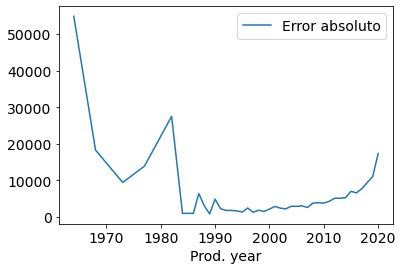

In [63]:

data_marca_means = data_filtered_test.groupby('Prod. year', as_index=False)['Error absoluto'].median()
data_marca_top_means = data_marca_means.sort_values(by="Prod. year")
data_marca_top_means.plot.line(x = "Prod. year")


De la gráfica vemos que con autos de modelos de entre 1990 y 2010, nuestro modelo suele tener un rendimiento correcto y no fallar por mucho (como 1 o 2 mil dólares máximo, pero teniendo en cuenta que hay autos de todo tipo de gama, esto no es tanto). 

Sin embargo, es de interés notar que parece que con los modelos de años más recientes este error ha ido subiendo y subiendo, lo cuál sería preocupante ya que para el equipo de negocio probablemente los carros más relevantes son justamente los de modelos más recientes, ya que en el futuro seguirán llegan cada vez modelos más nuevos.

Ahora, grafiquemos el top 10 de marcas con menor error promedio de nuestro modelo.

<AxesSubplot:xlabel='Manufacturer'>

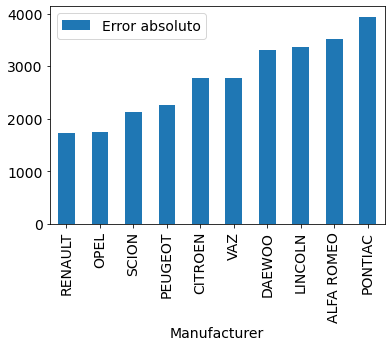

In [64]:
data_marca_means = data_filtered_test.groupby('Manufacturer', as_index=False)['Error absoluto'].mean()
data_marca_top_means = data_marca_means.sort_values(by="Error absoluto")[:10]
data_marca_top_means.plot.bar(x = "Manufacturer", y = "Error absoluto")

La gráfica anterior muestra que en marcas de carro como Renault y OPEL, el modelo lograra predecir muy bien los precios, fallando en promedio solamente en más o menos 1600 dólares para estos.

Adicionalmente, los árboles permiten ver cuáles fueron las varibles más usadas por el árbol, lo que da una noción de cuáles son las variables más importantes para modelar el precio de los vehículos.

<AxesSubplot:>

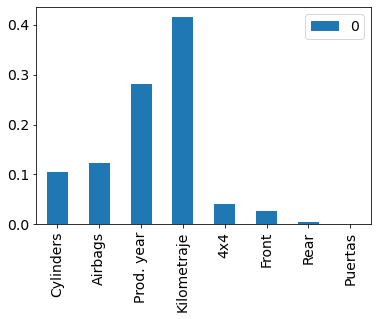

In [65]:
# Graficar feature importances para ver las variables más usadas por nuestro árbol
# Tener en cuenta que que en el modulo 4 profundizaremos mas en esteb tema
importancias_variables =  pd.DataFrame(modelo_final.feature_importances_, index = list(x_train_val.columns))
importancias_variables.plot.bar()

En la gráfica vemos que en el árbol las variables que más se usaron fueron Prod. Year y Kilometraje, lo que nos da una noción de que fueron las más importantes para este modelo (lo cual se alinea con lo que conocemos, y aquí es curioso ver que kilometraje sí se usa mucho en el modelo, a pesar de que su correlación lineal no era muy alta). Cilindros y airbags parecen estar en un segundo grado, mientras que puertas parece ser la menos usada. Recuerden que en el módulo 4 exploraremos más el tema de importancia de variables.

##### NOTA:
Sin embargo, tenga en cuenta que aquí solo estamos midiendo cuáles variables se usaron más en nuestro árbol, y no necesariamente cuáles eran más importantes para nuestro estudio. Las variables continuas se suelen usar muchas más veces puesto que tienen más posibles divisiones que las categóricas, lo que sesga las "importancias" que aquí vemos.



#### Ejercicio:
Cree una gráfica que permita responder la pregunta de negocio ""¿qué tan bien funciona nuestro modelo para predecir el precio para los autos de marca Toyota?" a través de una visualización.

Pista: grafique la distribución de errores para dicho escenario y analíce la gráfica.

### Validar si el modelo cumplió las expectativas de negocio y analíticas

Aquí deberíamos decidir si nuestro modelo elegido está cumpliendo o no los objetivos, tanto desde el punto de vista analítico como desde el punto de vista de negocio. 

Para este ejemplo, diremos que ya tenemos un modelo decente que está cumpliendo lo que esperábamos, por lo que podemos proceder con dicho modelo. Sin embargo, en un escenario real, debe aquí revisarse detenidamente si el modelo si es suficientemente bueno y sí cumple los objetivos planteados, y sus resultados deben ser aprobados por el equipo de negocio y el equipo analítica. Si no cumple las expectativas, habría que devolverse y buscar un nuevo modelo.


### Guardar el modelo final escogido
Ahora que vimos que el modelo cumplió las expectativas, puedo guardarlo en un pickle para que sea mi modelo final.
De esta forma, lo podré seguir usando cuando reciba datos nuevos.

In [66]:
# Lo ideal es volver a entrenar el modelo antes de guardarlo, pero ahora sí usando la totalidad de los datos
modelo_guardar = modelo_final.fit(data_x, data_y)


In [67]:
# Guardar el modelo en un pickle
import pickle as pk
pk.dump(modelo_guardar, open("modelo_final_escogido.pickle", 'wb'))

## 6. Despliegue

Ahora, vamos a la última etapa de CRISP-DM, el despliegue.

Analizaremos aquí como habilitar nuestro modelo para que pueda ser usado en el futuro para generar predicciones con nuevos datos, puesto que claramente este es el fin último para el cual lo creamos (para que pueda ser consumido por los usuarios).

#### Nota: 
Tener en cuenta que en un caso real, toda esta etapa de despliegue tendría más sentido que esté contenida en un programa aparte.
De esta forma, cuando un usuario final vaya a usar el modelo para generar nuevas predicciones, solo tendría que utilizar la parte de despliegue y ya, sin necesidad de correr ni mirar el código del resto de las etapas.

### Cargar datos nuevos

Empecemos por cargar primero los nuevos datos a los cuáles queremos generarle las predicciones.

In [68]:
# Cargar nuevos datos (seleccionarlos)
nuevos_datos = pd.read_csv("NewCarsPredict.csv")
nuevos_datos

,ID,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45794580,OPEL,Combo,2007,Goods wagon,No,Diesel,17 Turbo,136000 km,4.0,Manual,Front,04-May,Left wheel,Beige,4
1,45796788,NISSAN,Skyline,2003,Sedan,Yes,Petrol,3,220000 km,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,0
2,45769427,MERCEDES-BENZ,E 350,2014,Sedan,Yes,Diesel,3.5,219030 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12
3,45773726,MERCEDES-BENZ,E 350,2008,Sedan,Yes,Diesel,3.5,122874 km,6.0,Automatic,Rear,04-May,Left wheel,Black,12
4,45760891,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12
5,45772306,MERCEDES-BENZ,E 350,1923,Sedan,Yes,Diesel,3.5,217800 km,6.0,Automatic,Rear,04-May,Left wheel,Grey,12
6,45798355,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
7,45778856,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
8,45804997,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
9,45793526,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


### Preparar los nuevos datos

Ahora, preparar las columnas para que quede congruente a lo que esperaría nuestro modelo

##### Notar que tengo que repetir aquí las preparaciones de datos que hice.

Se sugiere por ende en un proyecto real usar "pipelines"; es decir, englobar todas las operaciones de preparación de datos en funciones y de esta forma aquí podría invocar dichas funciones sobre el nuevo conjunto de datos.

NOTA: Si incluyeron variables adicionales, deben asegurarse de agregarlas también aquí.
Y deben respetar el orden de las columnas que usaron al crear el modelo, esto es MUY IMPORTANTE.

In [69]:
# Funcion para preparar caracteristicas
def preparar_caract(df):

    # Seleccionar las columnas que sabiamos que ya estaban listas (obvio estos no tienen Precio)
    df_prep = df[["Cylinders", "Airbags", "Prod. year"]]   
    
    # Preparar kilometraje
    mileage = df["Mileage"]
    kilometraje = mileage.str.replace(" km", "")
    df_prep["Kilometraje"] = pd.to_numeric(kilometraje)
    
    # Preparar la de drive wheels (traccion llantas)
    onehot_wheels = pd.get_dummies(df["Drive wheels"])
    df_prep = df_prep.join(onehot_wheels)
    
    # Preparar la de puertas
    doorsdf = df[["Doors"]]
    orden = ['02-Mar','04-May','>5']
    enc = OrdinalEncoder(categories=[orden])
    doorsnew = enc.fit_transform(doorsdf)
    df_prep["Puertas"] = pd.DataFrame(doorsnew)
    
    ######### OJOOOO!!! Las columnas deben tener el mismo orden que tenian cuando prepare los datos originalmente #####
    # Debo asegurarme de que cuando despliegue, conserven el mismo orden.
    # si les cambio el orden, todo se dañara
    orden_cols = ['Cylinders', 'Airbags', 'Prod. year', 'Kilometraje', '4x4', 'Front', 'Rear', 'Puertas']
    df_prep = df_prep[orden_cols]
    
    return df_prep

Ahora que ya tenemos la función para preparar datos, ejecutemosla y veamos como quedan los datos.

In [70]:
nuevos_datos_prep = preparar_caract(nuevos_datos)
nuevos_datos_prep

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
0,4.0,4,2007,136000,0,1,0,1.0
1,6.0,0,2003,220000,0,0,1,1.0
2,6.0,12,2014,219030,1,0,0,1.0
3,6.0,12,2008,122874,0,0,1,1.0
4,4.0,12,2011,307325,0,1,0,1.0
5,6.0,12,1923,217800,0,0,1,1.0
6,4.0,5,1999,300000,0,0,1,0.0
7,4.0,8,2011,161600,0,1,0,1.0
8,4.0,4,2010,116365,0,1,0,1.0
9,4.0,4,2007,51258,0,1,0,1.0


Si se comparan con los datos preparados de mas arriba (por ejemplo, con los de x_test), notaremos que tienen la misma estructura, por lo que ha quedado correcta nuestra preparación. 

#### NOTA:
Es muy importante validar que estos nuevos datos hayan quedado preparados con el mismo formato, mismas columnas y mismo orden que los que usamos para entrenar el modelo. Si quedan diferentes, puede que ni siquiera nos demos cuenta y estaremos generando predicciones muy malas porque el modelo no sabe cuál columna es cual.

In [71]:
x_test.head()

,Cylinders,Airbags,Prod. year,Kilometraje,4x4,Front,Rear,Puertas
5483,4.0,10,2012,112000,0,1,0,1.0
8821,4.0,4,2015,409910,0,1,0,1.0
1215,6.0,12,2011,119379,1,0,0,1.0
3950,4.0,2,2004,229000,0,1,0,1.0
13558,4.0,10,2016,75851,0,1,0,1.0


### Cargar el modelo y generar y exportar las predicciones para los nuevos datos.

Ahora que ya tengo los nuevos datos preparados, procedemos a cargar el modelo y realizar y analizar las predicciones.

In [72]:
# Cargar el modelo escogido
modelo_escogido =  pk.load(open("modelo_final_escogido.pickle", "rb"))

In [73]:
# Predecir los nuevos valores
predichos = modelo_escogido.predict(nuevos_datos_prep)


In [74]:
# Juntarlos con las demás variables para poderlas analizar más fácil
nuevos_datos["Price_predicted"] = predichos
nuevos_datos

,ID,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Price_predicted
0,45794580,OPEL,Combo,2007,Goods wagon,No,Diesel,17 Turbo,136000 km,4.0,Manual,Front,04-May,Left wheel,Beige,4,6899.250000
1,45796788,NISSAN,Skyline,2003,Sedan,Yes,Petrol,3,220000 km,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,0,13250.250000
2,45769427,MERCEDES-BENZ,E 350,2014,Sedan,Yes,Diesel,3.5,219030 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12,29793.000000
3,45773726,MERCEDES-BENZ,E 350,2008,Sedan,Yes,Diesel,3.5,122874 km,6.0,Automatic,Rear,04-May,Left wheel,Black,12,22657.750000
4,45760891,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12,2168.833333
5,45772306,MERCEDES-BENZ,E 350,1923,Sedan,Yes,Diesel,3.5,217800 km,6.0,Automatic,Rear,04-May,Left wheel,Grey,12,47449.750000
6,45798355,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5,7401.200000
7,45778856,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8,16414.600000
8,45804997,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4,11486.400000
9,45793526,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4,7384.000000


### Analizar las predicciones generadas

Observando las predicciones, vemos que los valores que predice para la mayoría de los carros tienen sentido y se acomodan a lo que nos dice el sentido común.

Por ejemplo, notar que la predicción muy alta de 47 mil dólares corresponde a un Mercedes Benz de 1923, que al ser un auto clásico tendría sentido que se suba mucho su valor.

Note también que el más barato es un toyota prius de 2011 pero con 307 mil km, ya debe estar muy desgastado.

En general se notan predicciones que parecen ser válidas para muchos de los carros.

### Exportar las predicciones finales

Por último, lo que haríamos es exportar nuestras predicciones, por ejemplo a formato csv.

De esta forma, al equipo interesado en ellas le llevamos solamente el csv con las predicciones finales del modelo, sin necesidad de tener siempre que abrir el notebook donde las generamos para verlas.

Así también se puede conectar dichas predicciones con otros programas (con un aplicativo, una página web, una interfaz gráfica, etc) para llevarlas al usuario final.

In [75]:
nuevos_datos.to_csv("predicciones.csv", index=False)

Abrir y mirar el archivo csv para que vean como quedan dichas predicciones.

#### Ejercicio:
Cree un bloque de código que permita que un usuario ingrese una a una las características de su vehículo (usando "input") y al final, luego de ingresarlas todas, se genere la predicción para este.

### Sobre el monitoreo a futuro del modelo

La última etapa que haríamos desde código es tener en cuenta que hay que monitorear el modelo a futuro para ver que siga teniendo un buen rendimiento.

En este curso por temas de tiempo no trabajaremos esta etapa de monitoreo (se deja sugerida como posibilidad de estudio). Sin embargo, en un problema real, se debe ir monitoreando a través del tiempo como cambia el modelo. Por ejemplo, si yo lo volviera a correr un año después (con nuevos vehículos que ingresaron al conjunto de datos), y las métricas empeoran mucho, eso significa que el modelo se ha descalibrado y debo proceder a realizar un tratamiento para calibrar de nuevo este modelo.  
Esto puede ocurrir por algo que se llama "Data Drift" (la distribución de los datos cambió con el paso del tiempo y eso hace que nuestro modelo ya no sea tan bueno). Esto ocurrió en muchos modelos en el año 2020, ya que la pandemia por COVID-19 cambió la normalidad de muchas industrias y obviamente esto llevó a que los modelos, entrenados con datos que solo iban hasta 2019, se descalibrarán.

## Conclusión final

Por ende, ya habríamos por ahora terminado nuestro ejercicio siguiendo todas las etapas de CRISP-DM. 

Cómo se ha mencionado antes, este ejercicio es solo un ejemplo introductorio, pero en un caso aplicado a más profundidad (por ejemplo, en el del proyecto), se deben seguir con más detalle cada una de las etapas y hacer las tareas que quedaron sugeridas para dejarlo completo en su totalidad.

### Ejercicio sugerido a resolver:

1. Encuentre un modelo de árboles de decisión que supere las métricas del modelo aquí presentado en el conjunto de validación de dos formas:

a. Cambiando los hiperparámetros usados. 

b. Cambiando la parte de preparación de datos (selección de características).


2. Genere las métricas en el conjunto de prueba para dichos modelos. ¿Si superaban al anterior elegido?

3. Genere las predicciones de este modelo para el conjunto de datos externos a predecir (NewCarsPredict.csv).
Analice: según su conocimiento de vehículos, ¿tienen sentido estas predicciones? ¿Cuáles de ellas dan valores muy extraños?
